# BNPL Delinquency Risk Model: Technical Walkthrough

Full modeling pipeline: EDA, feature engineering, a temporal train/val/test split, a time-series cross-validated hyperparameter search, a logistic regression baseline vs. gradient-boosted trees, probability calibration, a cost-based decision threshold, SHAP interpretability, and a drift-monitoring check against a simulated macro shock.

For the short, stakeholder-facing version of this project see the [project README](../README.md).

All data here is synthetic, generated by `src/generate_data.py`. No proprietary data, models, or results from any employer are used or implied.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    roc_curve, precision_recall_curve, confusion_matrix,
)
import shap

from style import set_style, style_ax, savefig, add_footnote, SLATE, MUTED_TEAL, MUTED_RED, GREY, PALETTE
from features import engineer_features, build_feature_pipeline, RAW_FEATURE_COLS

set_style()
pd.set_option("display.max_columns", 50)
%matplotlib inline

## 1. Data

18k synthetic BNPL loans from 9k customers over a 24-month window. Customer demographics, a bureau-style credit score, prior repayment behavior, and loan terms. The target is `delinquent_30dpd`: whether the loan went 30+ days past due.

In [2]:
df = pd.read_csv("../data/loans.csv")
SOURCE_FULL = f"Source: synthetic BNPL loan data (src/generate_data.py) · n = {len(df):,} loans"
print(f"{len(df):,} loans, {df['customer_id'].nunique():,} customers")
print(f"Overall delinquency rate: {df['delinquent_30dpd'].mean():.2%}")
df.head()

18,092 loans, 9,144 customers
Overall delinquency rate: 14.23%


,loan_id,customer_id,origination_month,merchant_category,num_installments,loan_amount_usd,down_payment_ratio,age,city,city_tier,employment_type,monthly_income_usd,tenure_months_platform,num_previous_loans,credit_bureau_score,avg_prior_repayment_delay_days,num_active_loans_elsewhere,device_type,acquisition_channel,delinquent_30dpd
0,2797,1849,21,fashion,9,1366.31,0.348,39,Tier 2 metro,tier2,salaried,5724.45,39,5,436.0,2.5,0,ios,partner_store,0
1,10228,6851,24,fashion,6,1139.68,0.151,45,Tier 1 metro,tier1,self_employed,5136.39,29,6,397.0,0.0,1,android,organic,0
2,7771,5164,9,fashion,9,1396.21,0.260,30,Tier 2 metro,tier2,salaried,4240.10,40,6,499.0,2.5,1,android,partner_store,0
3,3288,2178,20,home_goods,3,2644.57,0.026,40,Tier 1 metro,tier1,gig_economy,9798.31,22,3,508.0,9.0,1,android,partner_store,0
4,5860,3885,23,electronics,9,2187.33,0.460,57,Tier 1 metro,tier1,salaried,13972.35,38,10,561.0,0.0,1,web,organic,0


## 2. Exploratory analysis

The last 3 months carry a synthetic macro shock (an inflation/rate spike) that raises delinquency without changing the input feature distributions. That gap is the basis for the drift-monitoring section at the end.

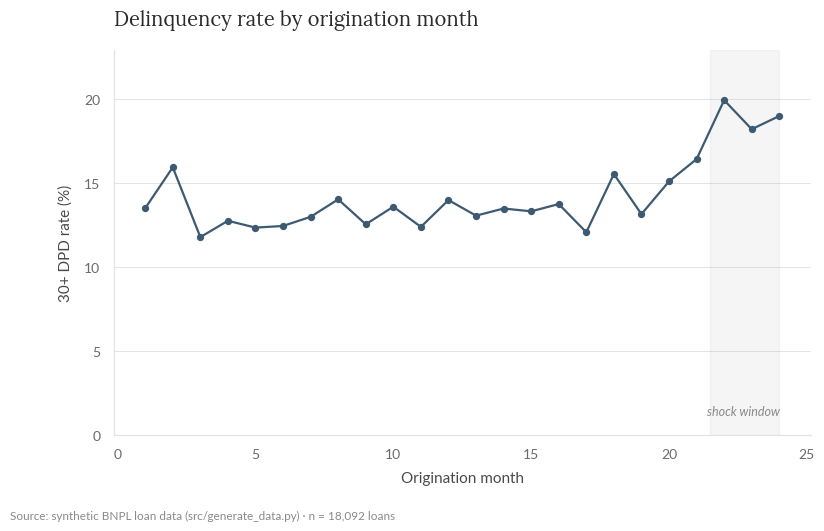

In [3]:
by_month = df.groupby("origination_month")["delinquent_30dpd"].mean()
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(by_month.index, by_month.values * 100, color=SLATE, linewidth=1.6)
ax.scatter(by_month.index, by_month.values * 100, color=SLATE, s=18, zorder=3)
ax.axvspan(21.5, 24, color=GREY, alpha=0.08)
ax.text(22.7, 1.2, "shock window", fontsize=9, color=GREY, ha="center", style="italic")
style_ax(ax, title="Delinquency rate by origination month",
         xlabel="Origination month", ylabel="30+ DPD rate (%)")
ax.set_ylim(0, by_month.values.max() * 100 * 1.15)
add_footnote(fig, SOURCE_FULL)
plt.show()

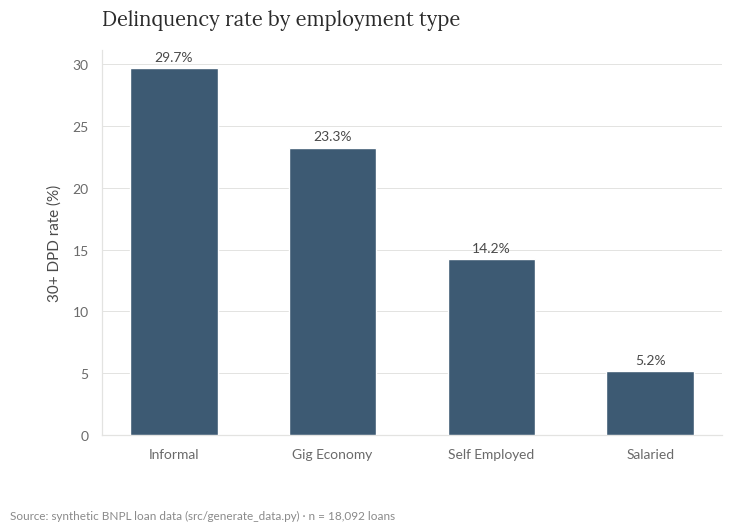

In [4]:
order = df.groupby("employment_type")["delinquent_30dpd"].mean().sort_values(ascending=False).index
rates = df.groupby("employment_type")["delinquent_30dpd"].mean().reindex(order) * 100
labels = [o.replace("_", " ").title() for o in order]
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(labels, rates.values, color=SLATE, width=0.55, zorder=3)
for i, v in enumerate(rates.values):
    ax.text(i, v + 0.6, f"{v:.1f}%", ha="center", fontsize=10, color="#4a4a4a")
style_ax(ax, title="Delinquency rate by employment type", ylabel="30+ DPD rate (%)")
add_footnote(fig, SOURCE_FULL)
plt.show()

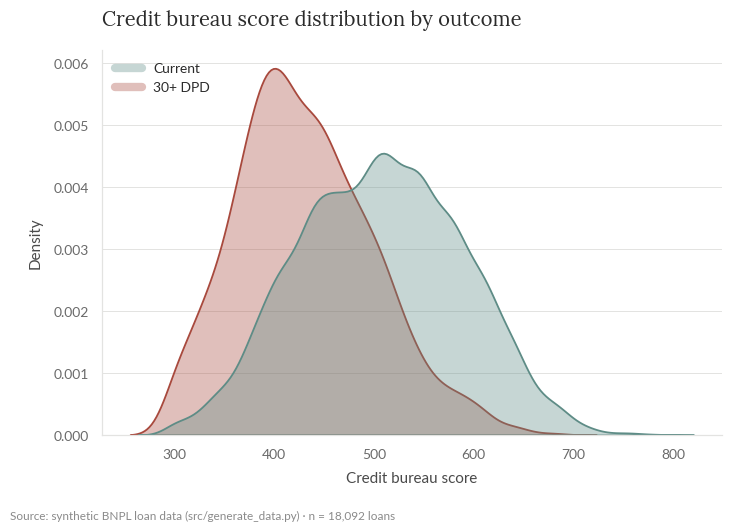

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.kdeplot(data=df, x="credit_bureau_score", hue="delinquent_30dpd", fill=True,
            common_norm=False, palette=[MUTED_TEAL, MUTED_RED], alpha=0.35, linewidth=1.3, ax=ax, legend=False)
ax.plot([], [], color=MUTED_TEAL, linewidth=6, alpha=0.35, label="Current")
ax.plot([], [], color=MUTED_RED, linewidth=6, alpha=0.35, label="30+ DPD")
ax.legend(loc="upper left")
style_ax(ax, title="Credit bureau score distribution by outcome",
         xlabel="Credit bureau score", ylabel="Density")
add_footnote(fig, SOURCE_FULL)
plt.show()

Bureau score, employment type, and the month-22-24 shock all show clear separation. Next: turn the raw loan/customer columns into a model-ready feature set.

## 3. Feature engineering

`engineer_features` adds ratios (loan-to-income, installment-to-income) and thin-file/new-customer flags with plain pandas. Everything that needs to be *fit* rather than just computed, missing-value imputation, outlier capping, categorical encoding, is built as a `feature-engine` pipeline (`build_feature_pipeline`) instead, wrapped in an sklearn `Pipeline`.

About 9% of customers have no bureau score on record (thin-file: gig/informal workers, recent platform joiners), a routine situation for a BNPL lender rather than an edge case. The pipeline adds a missing-value indicator for `credit_bureau_score`, then median-imputes it; both the missing-flag and the imputed value are just as real a signal as any other feature, and treating "no bureau record" as its own category (rather than silently dropping those rows or filling with something arbitrary) matters for a population this large.

In [6]:
df = engineer_features(df)
print(f"Missing bureau score: {df['credit_bureau_score'].isna().mean():.1%} of loans")

Missing bureau score: 9.4% of loans


## 4. Temporal train / validation / test split, then fit the feature pipeline

No random shuffling: a real deployment never sees the future at train time. Train on months 1-18, calibrate probabilities on 19-21, evaluate on 22-24 (which includes the shock, so the test set also doubles as the "monitored" window later on).

The feature pipeline is fit on the training split *only*, then applied unchanged (`.transform()`, never re-fit) to validation and test. This matters concretely here: the median used to impute a missing bureau score, and the IQR bounds used to cap outlier loan amounts and incomes, are training-window statistics. Fitting them on the full dataset first (as a single `build_design_matrix(df)` call before splitting would do) would let test-period data quietly influence how training-period rows get preprocessed.

In [7]:
train_df = df[df.origination_month <= 18]
val_df = df[(df.origination_month > 18) & (df.origination_month <= 21)]
test_df = df[df.origination_month > 21]

feature_pipeline = build_feature_pipeline()
X_train = feature_pipeline.fit_transform(train_df[RAW_FEATURE_COLS])
X_val = feature_pipeline.transform(val_df[RAW_FEATURE_COLS])
X_test = feature_pipeline.transform(test_df[RAW_FEATURE_COLS])
feature_names = list(X_train.columns)

y_train = train_df["delinquent_30dpd"].values
y_val = val_df["delinquent_30dpd"].values
y_test = test_df["delinquent_30dpd"].values

SOURCE_TEST = f"Source: synthetic BNPL loan data · held-out test set, months 22-24 · n = {len(test_df):,} loans"
print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}")
print(f"{X_train.shape[1]} features after the pipeline (incl. one-hot encoding and the missing-score indicator)")
X_train.head()

Train: 13,499 | Val: 2,347 | Test: 2,246
36 features after the pipeline (incl. one-hot encoding and the missing-score indicator)


,age,monthly_income_usd,tenure_months_platform,num_previous_loans,credit_bureau_score,avg_prior_repayment_delay_days,num_active_loans_elsewhere,num_installments,loan_amount_usd,down_payment_ratio,loan_to_income_ratio,installment_amount_usd,installment_to_income_ratio,low_bureau_score,is_new_customer,credit_bureau_score_na,city_tier_tier2,city_tier_tier3,city_tier_tier1,employment_type_salaried,employment_type_informal,employment_type_gig_economy,employment_type_self_employed,device_type_android,device_type_web,device_type_ios,acquisition_channel_partner_store,acquisition_channel_paid_social,acquisition_channel_organic,acquisition_channel_referral,merchant_category_fashion,merchant_category_electronics,merchant_category_travel,merchant_category_education,merchant_category_home_goods,merchant_category_groceries
2,30,4240.10,40,6,499.0,2.5,1,9,1396.21,0.260,0.329287,114.799489,0.027075,1,0,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,1,0,0,0,0,0
5,51,4258.81,37,5,506.0,0.0,0,6,1042.47,0.354,0.244780,112.239270,0.026355,1,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0
7,56,10343.08,22,0,550.0,0.0,1,9,1633.88,0.232,0.157968,139.424427,0.013480,1,0,0,0,0,1,1,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0
8,48,12144.95,27,4,563.0,1.5,4,3,1698.75,0.500,0.139873,283.125000,0.023312,1,0,0,0,0,1,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0
9,70,13393.72,34,1,640.0,0.0,2,6,679.83,0.165,0.050757,94.609675,0.007064,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0


## 5. Hyperparameter search (time-series cross-validation)

Hand-picked hyperparameters aren't a great look, and neither is validating on a single chronological split alone, since the reported AUC could just be a lucky or unlucky draw for that particular window. `TimeSeriesSplit` fits on an expanding window of months and validates on the months right after it, several times over, so the search picks hyperparameters that hold up across time rather than to one snapshot. The search only touches months 1-18 (the train region); the calibration window (19-21) and the true held-out test (22-24, with the shock) are never touched here.

In [8]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

train_sorted = train_df.sort_values("origination_month")
X_train_sorted = X_train.loc[train_sorted.index]
y_train_sorted = train_sorted["delinquent_30dpd"].values

param_distributions = {
    "max_depth": [3, 4, 5, 6, 7, None],
    "learning_rate": uniform(0.02, 0.18),
    "max_iter": randint(100, 500),
    "l2_regularization": uniform(0.0, 2.0),
    "max_leaf_nodes": [15, 31, 63, 127, None],
    "min_samples_leaf": randint(10, 60),
}

tscv = TimeSeriesSplit(n_splits=5)
search = RandomizedSearchCV(
    HistGradientBoostingClassifier(random_state=42, class_weight="balanced"),
    param_distributions, n_iter=30, scoring="roc_auc", cv=tscv, random_state=42, n_jobs=-1, refit=False,
)
search.fit(X_train_sorted, y_train_sorted)

cv_results = pd.DataFrame(search.cv_results_).sort_values("mean_test_score", ascending=False).reset_index(drop=True)
best_row = cv_results.iloc[0]
best_params = {k.replace("param_", ""): (v.item() if hasattr(v, "item") else v)
               for k, v in best_row.items() if k.startswith("param_")}

print(f"Best CV AUC: {best_row['mean_test_score']:.4f} +/- {best_row['std_test_score']:.4f}")
print("Best params:", best_params)

Best CV AUC: 0.8074 +/- 0.0046
Best params: {'l2_regularization': 1.7214611665126869, 'learning_rate': 0.021251383495614326, 'max_depth': 5, 'max_iter': 236, 'max_leaf_nodes': None, 'min_samples_leaf': 42}


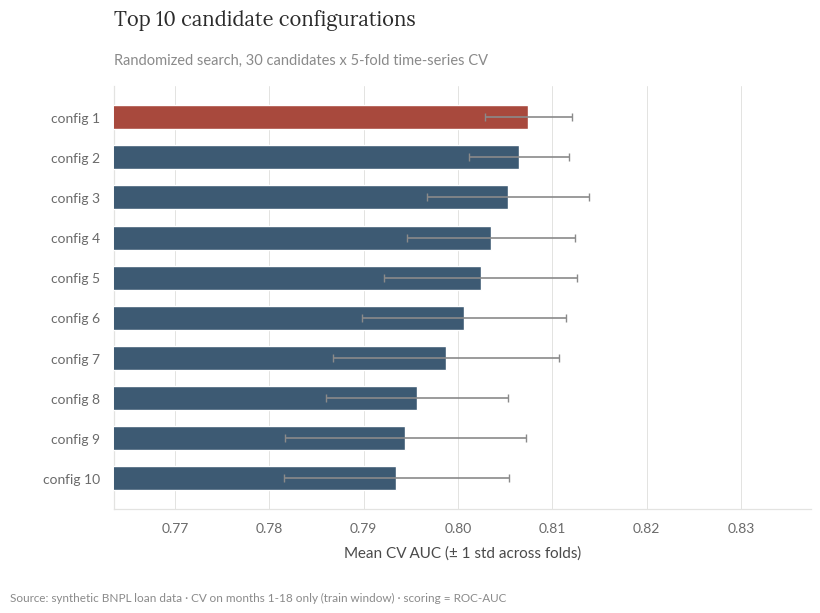

In [9]:
top10 = cv_results.head(10)
fig, ax = plt.subplots(figsize=(9, 5.5))
y_pos = np.arange(len(top10))[::-1]
colors = [MUTED_RED if i == 0 else SLATE for i in range(len(top10))]
ax.barh(y_pos, top10["mean_test_score"], xerr=top10["std_test_score"],
        color=colors, height=0.6, zorder=3, error_kw={"ecolor": GREY, "elinewidth": 1.2, "capsize": 3})
ax.set_yticks(y_pos)
ax.set_yticklabels([f"config {i+1}" for i in range(len(top10))])
ax.set_xlim(top10["mean_test_score"].min() - 0.03, top10["mean_test_score"].max() + 0.03)
style_ax(ax, title="Top 10 candidate configurations",
         subtitle="Randomized search, 30 candidates x 5-fold time-series CV",
         xlabel="Mean CV AUC (± 1 std across folds)", grid_axis="x")
add_footnote(fig, "Source: synthetic BNPL loan data · CV on months 1-18 only (train window) · scoring = ROC-AUC")
plt.show()

The gap between the top configs is small, mostly within one standard deviation of each other. That's useful information on its own: this model isn't hypersensitive to the exact hyperparameter choice, which is a healthier finding than a search that swings wildly between configs.

## 6. Modeling: logistic regression baseline vs. gradient-boosted trees

A regularized linear model as an interpretable benchmark, and `HistGradientBoostingClassifier`, using the tuned hyperparameters from the search above, as the main candidate.

In [10]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

logit = LogisticRegression(max_iter=2000, class_weight="balanced")
logit.fit(X_train_s, y_train)
logit_auc = roc_auc_score(y_test, logit.predict_proba(X_test_s)[:, 1])

gbm = HistGradientBoostingClassifier(
    **best_params, random_state=42, class_weight="balanced",
)
gbm.fit(X_train, y_train)
gbm_auc_raw = roc_auc_score(y_test, gbm.predict_proba(X_test)[:, 1])

print(f"Logistic regression AUC: {logit_auc:.3f}")
print(f"Gradient boosted trees AUC (raw): {gbm_auc_raw:.3f}")

Logistic regression AUC: 0.801
Gradient boosted trees AUC (raw): 0.791


The two are close. The underlying drivers here are close to additive, so a well-regularized linear model captures most of the signal. That's worth checking directly rather than assuming the more complex model wins by default.

## 7. Probability calibration

Raw GBM probabilities from tree ensembles tend to be overconfident. Isotonic calibration, fit on the untouched validation window (months 19-21), fixes this before any threshold or cost decision is made.

Brier score, raw: 0.1715 -> calibrated: 0.1259


/sessions/bold-sleepy-meitner/.local/lib/python3.10/site-packages/sklearn/calibration.py:330: FutureWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


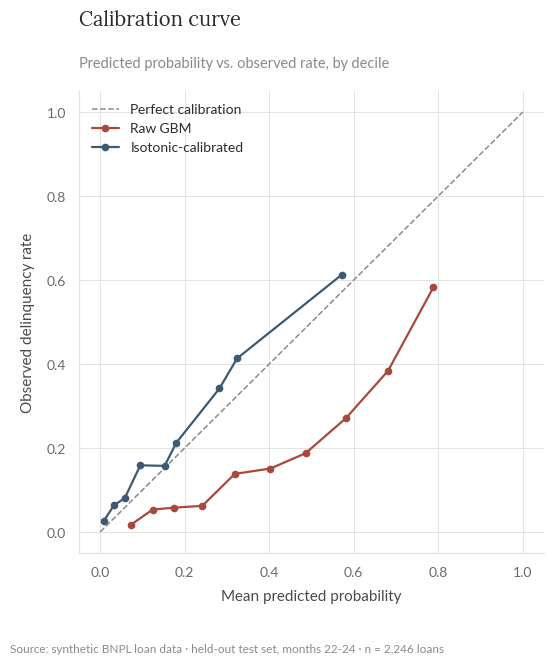

In [11]:
calibrated = CalibratedClassifierCV(gbm, method="isotonic", cv="prefit")
calibrated.fit(X_val, y_val)

y_prob_raw = gbm.predict_proba(X_test)[:, 1]
y_prob_test = calibrated.predict_proba(X_test)[:, 1]

brier_raw = brier_score_loss(y_test, y_prob_raw)
brier_cal = brier_score_loss(y_test, y_prob_test)
print(f"Brier score, raw: {brier_raw:.4f} -> calibrated: {brier_cal:.4f}")

frac_pos_raw, mean_pred_raw = calibration_curve(y_test, y_prob_raw, n_bins=10, strategy="quantile")
frac_pos_cal, mean_pred_cal = calibration_curve(y_test, y_prob_test, n_bins=10, strategy="quantile")

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", color=GREY, linewidth=1.1, label="Perfect calibration")
ax.plot(mean_pred_raw, frac_pos_raw, marker="o", markersize=4.5, color=MUTED_RED, linewidth=1.6, label="Raw GBM")
ax.plot(mean_pred_cal, frac_pos_cal, marker="o", markersize=4.5, color=SLATE, linewidth=1.6, label="Isotonic-calibrated")
style_ax(ax, title="Calibration curve",
         subtitle="Predicted probability vs. observed rate, by decile",
         xlabel="Mean predicted probability", ylabel="Observed delinquency rate", grid_axis="both")
ax.legend(loc="upper left")
add_footnote(fig, SOURCE_TEST)
plt.show()

## 8. Cost-based decision threshold

A missed delinquent loan (false negative) costs roughly 70% of principal net of recoveries; declining a good customer (false positive) forgoes about a 6% fee margin. Sweeping the threshold against these costs, instead of defaulting to 0.5, is what actually moves the P&L.

Cost-optimal threshold: 0.05
Expected cost at optimal threshold: $158,972
Expected cost at naive t=0.50: $476,835  (66.7% higher)


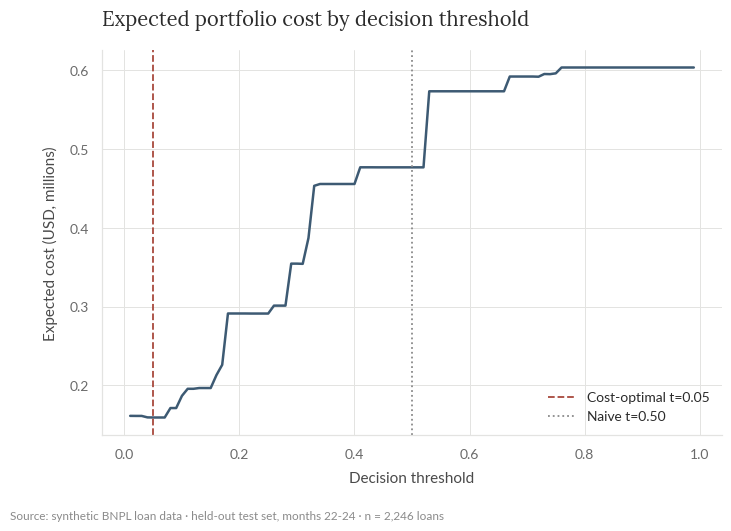

In [12]:
COST_FN_RATE = 0.70   # approved a loan that went delinquent
COST_FP_RATE = 0.06   # declined a loan that would have been repaid

loan_amounts = test_df["loan_amount_usd"].values
thresholds = np.linspace(0.01, 0.99, 99)
costs = []
for t in thresholds:
    pred = (y_prob_test >= t).astype(int)
    fn_mask = (pred == 0) & (y_test == 1)
    fp_mask = (pred == 1) & (y_test == 0)
    cost = (loan_amounts[fn_mask] * COST_FN_RATE).sum() + (loan_amounts[fp_mask] * COST_FP_RATE).sum()
    costs.append(cost)
costs = np.array(costs)
best_t = thresholds[costs.argmin()]
default_cost = costs[np.argmin(np.abs(thresholds - 0.5))]
best_cost = costs.min()

print(f"Cost-optimal threshold: {best_t:.2f}")
print(f"Expected cost at optimal threshold: ${best_cost:,.0f}")
print(f"Expected cost at naive t=0.50: ${default_cost:,.0f}  ({(1 - best_cost/default_cost):.1%} higher)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(thresholds, costs / 1e6, color=SLATE, linewidth=1.8)
ax.axvline(best_t, ls="--", color=MUTED_RED, linewidth=1.3, label=f"Cost-optimal t={best_t:.2f}")
ax.axvline(0.50, ls=":", color=GREY, linewidth=1.3, label="Naive t=0.50")
style_ax(ax, title="Expected portfolio cost by decision threshold",
         xlabel="Decision threshold", ylabel="Expected cost (USD, millions)", grid_axis="both")
ax.legend()
add_footnote(fig, SOURCE_TEST)
plt.show()

The optimal threshold sits far below 0.5: a missed delinquent loan costs about 12x more than declining a good customer, so the model should approve conservatively even at the expense of precision.

## 9. Held-out performance at the chosen threshold

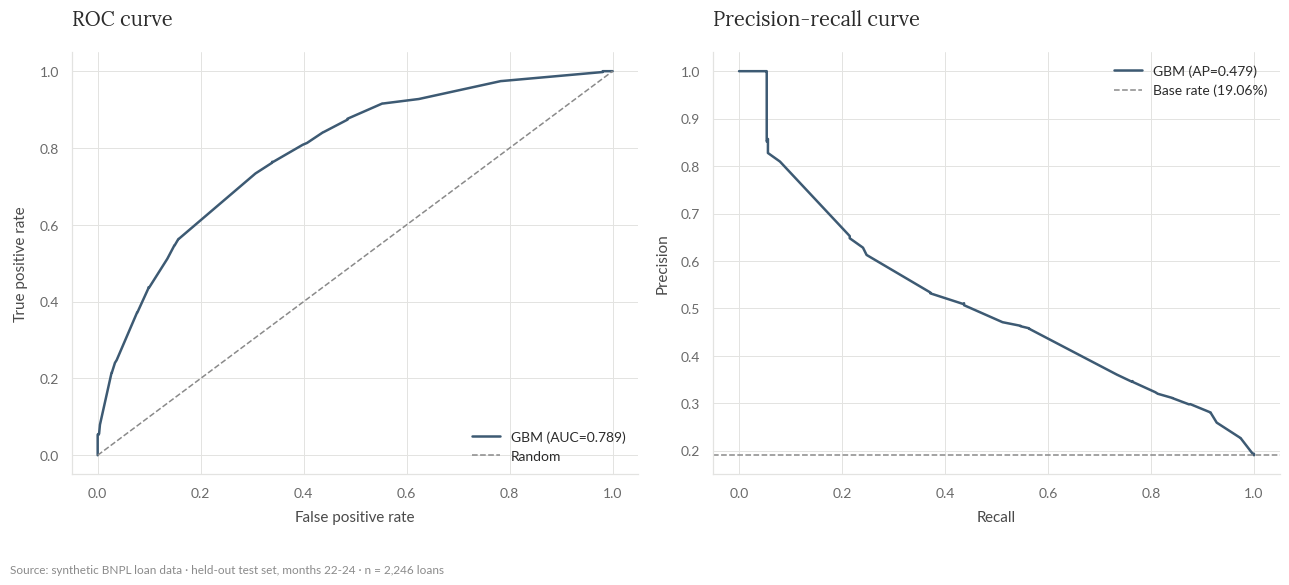

In [13]:
auc = roc_auc_score(y_test, y_prob_test)
ap = average_precision_score(y_test, y_prob_test)
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
prec, rec, _ = precision_recall_curve(y_test, y_prob_test)
base_rate = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
axes[0].plot(fpr, tpr, color=SLATE, linewidth=1.8, label=f"GBM (AUC={auc:.3f})")
axes[0].plot([0, 1], [0, 1], "--", color=GREY, linewidth=1.1, label="Random")
style_ax(axes[0], title="ROC curve", xlabel="False positive rate", ylabel="True positive rate", grid_axis="both")
axes[0].legend(loc="lower right")

axes[1].plot(rec, prec, color=SLATE, linewidth=1.8, label=f"GBM (AP={ap:.3f})")
axes[1].axhline(base_rate, ls="--", color=GREY, linewidth=1.1, label=f"Base rate ({base_rate:.2%})")
style_ax(axes[1], title="Precision-recall curve", xlabel="Recall", ylabel="Precision", grid_axis="both")
axes[1].legend(loc="upper right")
plt.tight_layout()
add_footnote(fig, SOURCE_TEST)
plt.show()

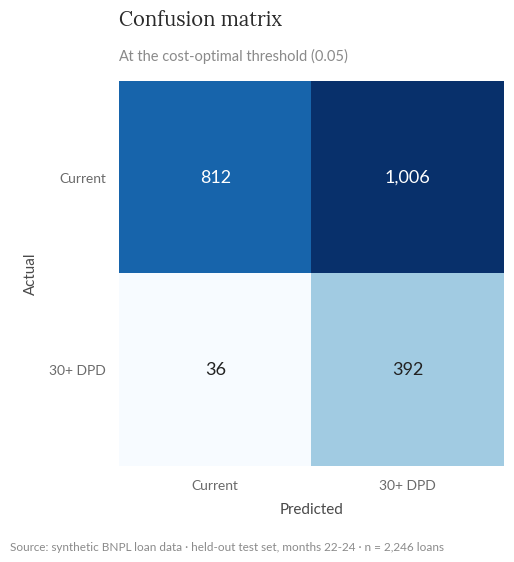

Precision: 0.280 | Recall: 0.916


In [14]:
y_pred_best = (y_prob_test >= best_t).astype(int)
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Current", "30+ DPD"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Current", "30+ DPD"])
ax.grid(False)
for spine in ax.spines.values():
    spine.set_visible(False)
style_ax(ax, title="Confusion matrix",
         subtitle=f"At the cost-optimal threshold ({best_t:.2f})", xlabel="Predicted", ylabel="Actual", grid_axis=None)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f"{cm[i, j]:,}", ha="center", va="center", fontsize=13,
                 color="white" if cm[i, j] > cm.max() / 2 else "#222222")
add_footnote(fig, SOURCE_TEST)
plt.show()

print(f"Precision: {precision:.3f} | Recall: {recall:.3f}")

In [15]:
pd.DataFrame({
    "Metric": ["Logistic regression AUC", "GBM AUC", "GBM PR-AUC (AP)",
               "Brier (raw)", "Brier (calibrated)", "Cost-optimal threshold",
               "Precision @ threshold", "Recall @ threshold", "Cost reduction vs. naive t=0.5"],
    "Value": [f"{logit_auc:.3f}", f"{auc:.3f}", f"{ap:.3f}", f"{brier_raw:.4f}", f"{brier_cal:.4f}",
              f"{best_t:.2f}", f"{precision:.3f}", f"{recall:.3f}",
              f"{(1 - best_cost/default_cost):.1%}"],
})

,Metric,Value
0,Logistic regression AUC,0.801
1,GBM AUC,0.789
2,GBM PR-AUC (AP),0.479
3,Brier (raw),0.1715
4,Brier (calibrated),0.1259
5,Cost-optimal threshold,0.05
6,Precision @ threshold,0.280
7,Recall @ threshold,0.916
8,Cost reduction vs. naive t=0.5,66.7%


## 10. Interpretability (SHAP)

Tree SHAP values on the held-out set, to check the model is picking up sensible, defensible drivers rather than noise.

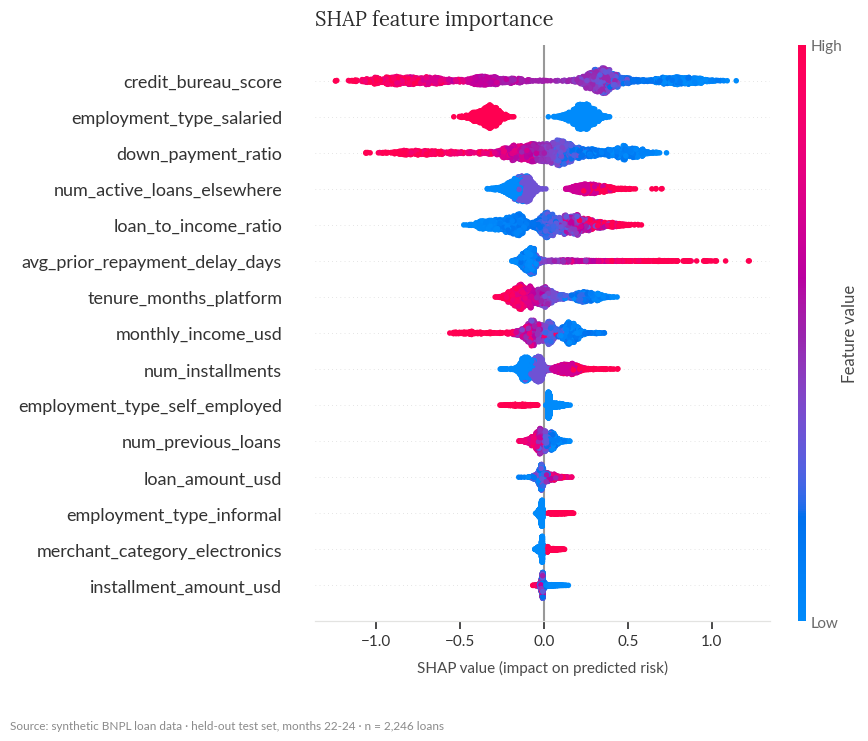

In [16]:
explainer = shap.TreeExplainer(gbm)
shap_values = explainer(X_test)

fig = plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_test, show=False, max_display=15, plot_size=None)
ax = plt.gca()
ax.set_title("SHAP feature importance", loc="left", fontsize=14.5, fontweight="normal",
             fontfamily="Lora", color="#2B2B2B", pad=14)
ax.set_xlabel("SHAP value (impact on predicted risk)", fontsize=11, labelpad=8)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
add_footnote(fig, SOURCE_TEST)
plt.tight_layout()
plt.show()

Bureau score, employment type, down payment ratio, and existing loans elsewhere dominate, consistent with the EDA and with standard credit-risk intuition. The missing-bureau-score indicator itself (`credit_bureau_score_na`) also carries a small amount of separate signal, ranking well below the top features but non-zero, meaning "no bureau record" isn't fully redundant with the other applicant information already available.

## 11. Monitoring: drift after the macro shock

Comparing the training population (months 1-21) against the shocked window (22-24, held out from training). Three checks: input feature drift (PSI, on observed values), the missing-bureau-score *rate* itself (a shift here wouldn't show up in PSI, since PSI only covers values that were actually observed), and outcome/calibration drift.

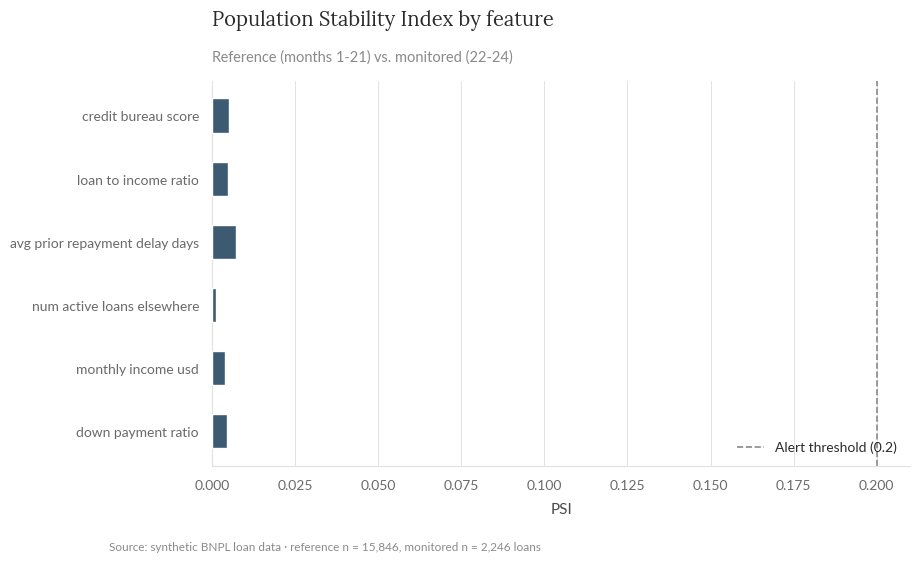

{'credit_bureau_score': 0.0049, 'loan_to_income_ratio': 0.0047, 'avg_prior_repayment_delay_days': 0.0072, 'num_active_loans_elsewhere': 0.001, 'monthly_income_usd': 0.0038, 'down_payment_ratio': 0.0043}
Missing bureau score rate: 9.4% (reference) vs. 9.9% (monitored)


In [17]:
def psi(reference, current, bins=10):
    # PSI is computed on observed values only; the missing-rate itself is
    # checked separately just below, since it's a different kind of drift.
    reference = reference[~np.isnan(reference)]
    current = current[~np.isnan(current)]
    cut_points = np.unique(np.quantile(reference, np.linspace(0, 1, bins + 1)))
    if len(cut_points) < 3:
        return 0.0
    ref_counts, _ = np.histogram(reference, bins=cut_points)
    cur_counts, _ = np.histogram(current, bins=cut_points)
    ref_pct = np.clip(ref_counts / max(ref_counts.sum(), 1), 1e-4, None)
    cur_pct = np.clip(cur_counts / max(cur_counts.sum(), 1), 1e-4, None)
    return float(np.sum((cur_pct - ref_pct) * np.log(cur_pct / ref_pct)))

reference = df[df.origination_month <= 21]
monitored = df[df.origination_month > 21]
SOURCE_DRIFT = f"Source: synthetic BNPL loan data · reference n = {len(reference):,}, monitored n = {len(monitored):,} loans"
MONITORED_FEATURES = ["credit_bureau_score", "loan_to_income_ratio", "avg_prior_repayment_delay_days",
                       "num_active_loans_elsewhere", "monthly_income_usd", "down_payment_ratio"]
PSI_ALERT = 0.20

psi_results = {f: round(psi(reference[f].values, monitored[f].values), 4) for f in MONITORED_FEATURES}

fig, ax = plt.subplots(figsize=(9, 5))
feats = [f.replace("_", " ") for f in psi_results.keys()]
vals = list(psi_results.values())
colors = [MUTED_RED if v > PSI_ALERT else SLATE for v in vals]
ax.barh(feats, vals, color=colors, zorder=3, height=0.55)
ax.axvline(PSI_ALERT, ls="--", color=GREY, linewidth=1.2, label=f"Alert threshold ({PSI_ALERT})")
ax.invert_yaxis()
style_ax(ax, title="Population Stability Index by feature",
         subtitle="Reference (months 1-21) vs. monitored (22-24)",
         xlabel="PSI", grid_axis="x")
ax.legend(loc="lower right")
add_footnote(fig, SOURCE_DRIFT)
plt.show()

missing_rate_reference = float(reference["credit_bureau_score"].isna().mean())
missing_rate_monitored = float(monitored["credit_bureau_score"].isna().mean())
print(psi_results)
print(f"Missing bureau score rate: {missing_rate_reference:.1%} (reference) vs. {missing_rate_monitored:.1%} (monitored)")

Mean predicted probability (monitored window): 15.49%
Observed delinquency rate (monitored window): 19.06%
Calibration gap: 3.56%


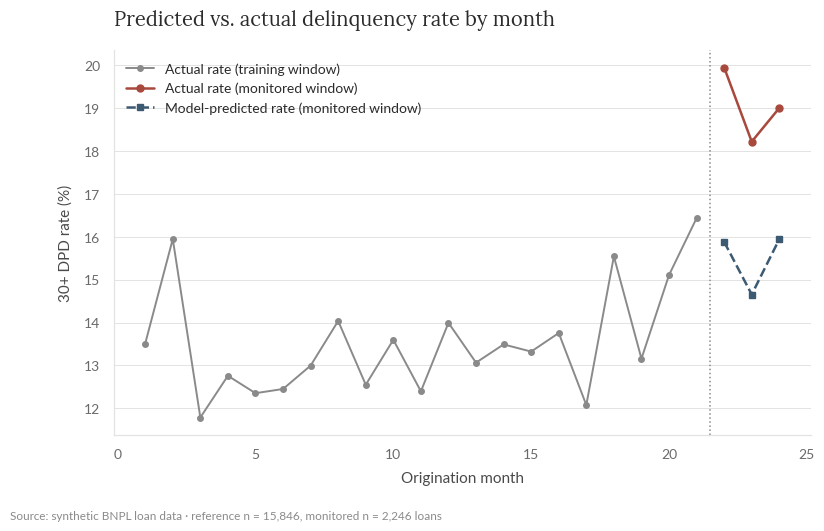

In [18]:
# Transform only, with the pipeline fit on the training split above:
# scoring the monitored window with statistics re-fit on it would defeat
# the point of a frozen, deployed model.
X_monitored = feature_pipeline.transform(monitored[RAW_FEATURE_COLS])
y_monitored = monitored["delinquent_30dpd"].values
y_prob_monitored = calibrated.predict_proba(X_monitored)[:, 1]

mean_pred = y_prob_monitored.mean()
observed_rate = y_monitored.mean()
print(f"Mean predicted probability (monitored window): {mean_pred:.2%}")
print(f"Observed delinquency rate (monitored window): {observed_rate:.2%}")
print(f"Calibration gap: {observed_rate - mean_pred:.2%}")

monitored_scored = monitored.copy()
monitored_scored["pred_prob"] = y_prob_monitored
by_month_m = monitored_scored.groupby("origination_month").agg(
    actual_rate=("delinquent_30dpd", "mean"), predicted_rate=("pred_prob", "mean"))
ref_by_month = reference.groupby("origination_month")["delinquent_30dpd"].mean()

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(ref_by_month.index, ref_by_month.values * 100, marker="o", markersize=4, color=GREY, linewidth=1.4,
        label="Actual rate (training window)")
ax.plot(by_month_m.index, by_month_m["actual_rate"] * 100, marker="o", markersize=5, color=MUTED_RED, linewidth=1.8,
        label="Actual rate (monitored window)")
ax.plot(by_month_m.index, by_month_m["predicted_rate"] * 100, marker="s", markersize=5, ls="--", color=SLATE, linewidth=1.8,
        label="Model-predicted rate (monitored window)")
ax.axvline(21.5, ls=":", color=GREY, linewidth=1.1)
style_ax(ax, title="Predicted vs. actual delinquency rate by month",
         xlabel="Origination month", ylabel="30+ DPD rate (%)")
ax.legend(fontsize=10, loc="upper left")
add_footnote(fig, SOURCE_DRIFT)
plt.show()

PSI flags nothing: every monitored feature is well under the 0.20 alert threshold, yet the observed delinquency rate jumps and the model, calibrated only on pre-shock data, under-predicts it. This is concept drift, not covariate drift. The inputs look the same, but the relationship between inputs and outcome changed. A monitoring setup that only checks input PSI would miss it; pairing it with outcome-rate and calibration monitoring catches it.

## 12. Rate-mix shift: composition change or true rate change?

Clean PSI rules out one alternative explanation (individual feature distributions haven't shifted), but not a subtler one: the portfolio's *composition* across segments could have quietly shifted toward ones that were already riskier, which would raise the blended delinquency rate without any single feature's marginal distribution moving enough to trip a PSI alert. A rate-mix shift decomposition checks this directly, splitting the change in the blended rate into a mix effect (composition shift) and a rate effect (within-segment rate change), using a symmetric bridge decomposition that sums to the observed change exactly with no unexplained residual:

```
mix_effect(segment)  = (w_b - w_a) * (r_a + r_b) / 2
rate_effect(segment) = (w_a + w_b) / 2 * (r_b - r_a)
```

where `w` is a segment's share of loans and `r` is its delinquency rate, comparing the reference window (months 1-21) to the monitored window (22-24).

In [19]:
def decompose_rate_mix_shift(weights_a, rates_a, weights_b, rates_b):
    segments = sorted(set(weights_a.index) | set(weights_b.index))
    w_a = weights_a.reindex(segments, fill_value=0.0)
    w_b = weights_b.reindex(segments, fill_value=0.0)
    r_a = rates_a.reindex(segments, fill_value=0.0)
    r_b = rates_b.reindex(segments, fill_value=0.0)
    mix_effect = (w_b - w_a) * (r_a + r_b) / 2
    rate_effect = (w_a + w_b) / 2 * (r_b - r_a)
    total_delta = float((w_b * r_b).sum() - (w_a * r_a).sum())
    return {"segments": segments, "mix_effect": mix_effect, "rate_effect": rate_effect,
            "total_delta": total_delta, "mix_total": float(mix_effect.sum()), "rate_total": float(rate_effect.sum())}

def segment_weights_and_rates(frame, col):
    return frame.groupby(col).size() / len(frame), frame.groupby(col)["delinquent_30dpd"].mean()

SEGMENT = "employment_type"
w_a, r_a = segment_weights_and_rates(reference, SEGMENT)
w_b, r_b = segment_weights_and_rates(monitored, SEGMENT)
result = decompose_rate_mix_shift(w_a, r_a, w_b, r_b)
mix_share = result["mix_total"] / result["total_delta"]
rate_share = result["rate_total"] / result["total_delta"]

print(f"Overall delinquency-rate change: {result['total_delta']:+.3%}")
print(f"Mix effect: {result['mix_total']:+.3%} ({mix_share:.1%} of the change)")
print(f"Rate effect: {result['rate_total']:+.3%} ({rate_share:.1%} of the change)")

Overall delinquency-rate change: +5.507%
Mix effect: +0.197% (3.6% of the change)
Rate effect: +5.310% (96.4% of the change)


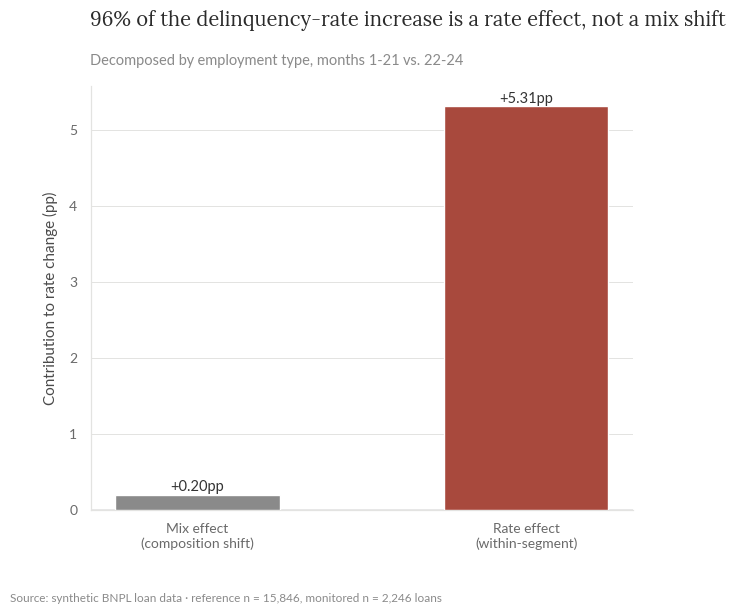

In [20]:
fig, ax = plt.subplots(figsize=(7, 5.5))
bars = ["Mix effect\n(composition shift)", "Rate effect\n(within-segment)"]
vals = [result["mix_total"] * 100, result["rate_total"] * 100]
ax.bar(bars, vals, color=[GREY, MUTED_RED], width=0.5, zorder=3)
ax.axhline(0, color=GREY, linewidth=1)
for i, v in enumerate(vals):
    ax.text(i, v + (0.05 if v >= 0 else -0.15), f"{v:+.2f}pp", ha="center", fontsize=10.5, color="#333")
style_ax(ax, title=f"{rate_share:.0%} of the delinquency-rate increase is a rate effect, not a mix shift",
         subtitle=f"Decomposed by {SEGMENT.replace('_', ' ')}, months 1-21 vs. 22-24", ylabel="Contribution to rate change (pp)")
add_footnote(fig, SOURCE_DRIFT)
plt.show()

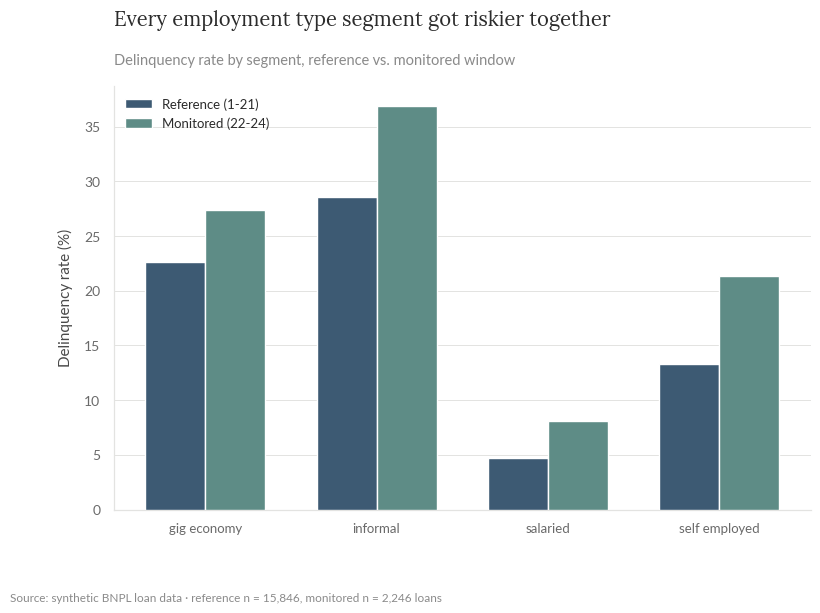

Robustness check across other segment dimensions:
  city_tier: rate effect = 101.1% of the change
  merchant_category: rate effect = 100.4% of the change
  acquisition_channel: rate effect = 100.0% of the change


In [21]:
segs = result["segments"]
x = np.arange(len(segs))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.bar(x - width/2, r_a.reindex(segs, fill_value=0) * 100, width, color=SLATE, label="Reference (1-21)", zorder=3)
ax.bar(x + width/2, r_b.reindex(segs, fill_value=0) * 100, width, color=MUTED_TEAL, label="Monitored (22-24)", zorder=3)
ax.set_xticks(x); ax.set_xticklabels([s.replace("_", " ") for s in segs], fontsize=9.5)
style_ax(ax, title=f"Every {SEGMENT.replace('_', ' ')} segment got riskier together",
         subtitle="Delinquency rate by segment, reference vs. monitored window", ylabel="Delinquency rate (%)")
ax.legend(fontsize=9.5, loc="upper left")
add_footnote(fig, SOURCE_DRIFT)
plt.show()

print("Robustness check across other segment dimensions:")
for seg in ["city_tier", "merchant_category", "acquisition_channel"]:
    wa, ra = segment_weights_and_rates(reference, seg)
    wb, rb = segment_weights_and_rates(monitored, seg)
    res = decompose_rate_mix_shift(wa, ra, wb, rb)
    print(f"  {seg}: rate effect = {res['rate_total']/res['total_delta']:.1%} of the change")

Across every segment dimension checked, 96-101% of the increase is a rate effect. The portfolio's composition barely moved; every employment segment simply got riskier together. That rules out "the mix quietly shifted toward riskier customers" as the explanation and points squarely at the model: it needs recalibration (or retraining) on shock-period data, not a change in who gets approved.

## 13. Limitations

- Synthetic data with hand-specified, mostly-linear relationships. Real portfolios have messier, more interacting effects and label noise.
- The hyperparameter search covers the GBM's own parameters; it doesn't try monotonic constraints on features like bureau score, which a real project would probably test given the model is used for risk decisions.
- The cost assumptions (70% loss given default, 6% margin) are illustrative, not fitted from real recovery data.
- The 3-month monitored window is short. Production monitoring would track PSI and calibration continuously, not as a one-off snapshot.
- The rate-mix shift decomposition is only as informative as the segment dimensions checked; a mix shift along some other, unexamined dimension can't be ruled out completely.